In [3]:
from google.colab import files
uploaded = files.upload()  # a button will appear to upload your CSV

In [22]:
import pandas as pd
df = pd.read_csv('sdud2025.csv')

In [5]:
df.head()

,Utilization Type,State,NDC,Labeler Code,Product Code,Package Size,Year,Quarter,Suppression Used,Product Name,Units Reimbursed,Number of Prescriptions,Total Amount Reimbursed,Medicaid Amount Reimbursed,Non Medicaid Amount Reimbursed
0,FFSU,AK,2143380,2,1433,80,2025,2,False,TRULICITY,216.0,107.0,102976.40,98630.87,4345.53
1,FFSU,AK,2143480,2,1434,80,2025,2,False,TRULICITY,218.0,109.0,104481.92,101806.64,2675.28
2,FFSU,AK,2143611,2,1436,11,2025,2,False,EMGALITY P,21.0,20.0,15227.25,15227.25,0.00
3,FFSU,AK,2144511,2,1445,11,2025,2,False,TALTZ AUTO,33.0,30.0,231532.28,231532.28,0.00
4,FFSU,AK,2144527,2,1445,27,2025,2,True,TALTZ AUTO,NaN,NaN,NaN,NaN,NaN


In [6]:
glp1_keywords = [
    'semaglutide', 'ozempic', 'wegovy', 'rybelsus',
    'tirzepatide', 'mounjaro', 'zepbound',
    'liraglutide', 'victoza', 'saxenda',
    'dulaglutide', 'trulicity',
    'exenatide', 'byetta', 'bydureon'
]

df['Product Name Lower'] = df['Product Name'].str.lower()
mask = df['Product Name Lower'].str.contains('|'.join(glp1_keywords), na=False)
glp1 = df[mask].copy()
print(f"GLP-1 rows found: {len(glp1)}")

GLP-1 rows found: 2020


In [7]:
glp1 = glp1[glp1['Suppression Used'] == False].copy()
print(f"Rows after removing suppressed: {len(glp1)}")

Rows after removing suppressed: 1455


In [8]:
def clean_product_name(name):
    name = name.strip()
    if 'OZEMPIC' in name:     return 'OZEMPIC'
    if 'WEGOVY' in name:      return 'WEGOVY'
    if 'RYBELSUS' in name:    return 'RYBELSUS'
    if 'MOUNJARO' in name:    return 'MOUNJARO'
    if 'ZEPBOUND' in name:    return 'ZEPBOUND'
    if 'VICTOZA' in name:     return 'VICTOZA'
    if 'SAXENDA' in name:     return 'SAXENDA'
    if 'TRULICITY' in name:   return 'TRULICITY'
    if 'BYETTA' in name:      return 'BYETTA'
    if 'BYDUREON' in name:    return 'BYDUREON'
    if 'EXENATIDE' in name:   return 'EXENATIDE'
    if 'LIRAGLUTIDE' in name: return 'LIRAGLUTIDE'
    if 'SEMAGLUTIDE' in name: return 'SEMAGLUTIDE'
    if 'DULAGLUTIDE' in name: return 'DULAGLUTIDE'
    if 'TIRZEPATIDE' in name: return 'TIRZEPATIDE'
    return name

glp1['Product Name'] = glp1['Product Name'].apply(clean_product_name)
print(glp1['Product Name'].unique())

['TRULICITY' 'MOUNJARO' 'ZEPBOUND' 'OZEMPIC' 'RYBELSUS' 'VICTOZA'
 'BYDUREON' 'WEGOVY' 'BYETTA' 'SAXENDA']


In [9]:
glp1['Coverage Rate'] = glp1['Medicaid Amount Reimbursed'] / glp1['Total Amount Reimbursed']

def assign_bucket(rate):
    if rate < 0.5:
        return 0   # Low
    elif rate <= 0.8:
        return 1   # Medium
    else:
        return 2   # High

glp1['Coverage Bucket'] = glp1['Coverage Rate'].apply(assign_bucket)
print(glp1['Coverage Bucket'].value_counts())

Coverage Bucket
2    1303
1      99
0      53
Name: count, dtype: int64


In [10]:
glp1['Coverage Rate'] = glp1['Medicaid Amount Reimbursed'] / glp1['Total Amount Reimbursed']

glp1['Coverage Bucket'] = (glp1['Coverage Rate'] > 0.8).astype(int)

print(glp1['Coverage Bucket'].value_counts())
print(f"\n0 = Low/Medium (Medicaid covers ≤80%)")
print(f"1 = High (Medicaid covers >80%)")

Coverage Bucket
1    1303
0     152
Name: count, dtype: int64

0 = Low/Medium (Medicaid covers ≤80%)
1 = High (Medicaid covers >80%)


In [11]:
drop_cols = [
    'NDC', 'Labeler Code', 'Product Code', 'Package Size',
    'Year', 'Suppression Used',
    'Total Amount Reimbursed', 'Medicaid Amount Reimbursed',
    'Non Medicaid Amount Reimbursed',
    'Coverage Rate', 'Product Name Lower'
]

glp1 = glp1.drop(columns=drop_cols)
print(glp1.shape)
print(glp1.columns.tolist())

(1455, 7)
['Utilization Type', 'State', 'Quarter', 'Product Name', 'Units Reimbursed', 'Number of Prescriptions', 'Coverage Bucket']


In [12]:
X = glp1[['State', 'Product Name', 'Utilization Type', 'Quarter',
           'Units Reimbursed', 'Number of Prescriptions']]
y = glp1['Coverage Bucket']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nClass distribution:")
print(y.value_counts())

X shape: (1455, 6)
y shape: (1455,)

Class distribution:
Coverage Bucket
1    1303
0     152
Name: count, dtype: int64


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train size: {X_train.shape[0]} rows")
print(f"Test size:  {X_test.shape[0]} rows")
print(f"\nTrain class distribution:")
print(y_train.value_counts())
print(f"\nTest class distribution:")
print(y_test.value_counts())

Train size: 1164 rows
Test size:  291 rows

Train class distribution:
Coverage Bucket
1    1042
0     122
Name: count, dtype: int64

Test class distribution:
Coverage Bucket
1    261
0     30
Name: count, dtype: int64


In [14]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X_train = X_train.copy()
X_test = X_test.copy()
X_train['Quarter'] = X_train['Quarter'].astype(str)
X_test['Quarter']  = X_test['Quarter'].astype(str)

categorical_cols = ['State', 'Product Name', 'Utilization Type', 'Quarter']
numerical_cols   = ['Units Reimbursed', 'Number of Prescriptions']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])

print("Pipeline built successfully!")

Pipeline built successfully!


In [15]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

# Get feature names
ohe_features = preprocessor.named_transformers_['cat']\
    .get_feature_names_out(categorical_cols).tolist()
all_features = numerical_cols + ohe_features

print(f"Total features after encoding: {len(all_features)}")

Total features after encoding: 37


In [16]:
train_df = pd.DataFrame(X_train_processed, columns=all_features)
train_df['Coverage Bucket'] = y_train.values

test_df = pd.DataFrame(X_test_processed, columns=all_features)
test_df['Coverage Bucket'] = y_test.values

train_df.to_csv('glp1_train.csv', index=False)
test_df.to_csv('glp1_test.csv', index=False)

print(f"glp1_train.csv saved: {train_df.shape}")
print(f"glp1_test.csv saved: {test_df.shape}")

glp1_train.csv saved: (1164, 38)
glp1_test.csv saved: (291, 38)


In [17]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

train_df = pd.read_csv('glp1_train.csv')
test_df  = pd.read_csv('glp1_test.csv')

X_train = train_df.drop(columns=['Coverage Bucket'])
y_train = train_df['Coverage Bucket']

X_test  = test_df.drop(columns=['Coverage Bucket'])
y_test  = test_df['Coverage Bucket']

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (1164, 37), Test: (291, 37)


In [18]:
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

cv_scores = cross_val_score(lr_model, X_train, y_train, cv=5, scoring='f1')

print(f"5-Fold CV F1 Scores: {cv_scores.round(3)}")
print(f"Mean F1: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

5-Fold CV F1 Scores: [0.934 0.953 0.911 0.947 0.917]
Mean F1: 0.932 (+/- 0.016)


In [19]:
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['Low/Medium (0)', 'High (1)']))

                precision    recall  f1-score   support

Low/Medium (0)       0.43      1.00      0.60        30
      High (1)       1.00      0.85      0.92       261

      accuracy                           0.86       291
     macro avg       0.71      0.92      0.76       291
  weighted avg       0.94      0.86      0.88       291



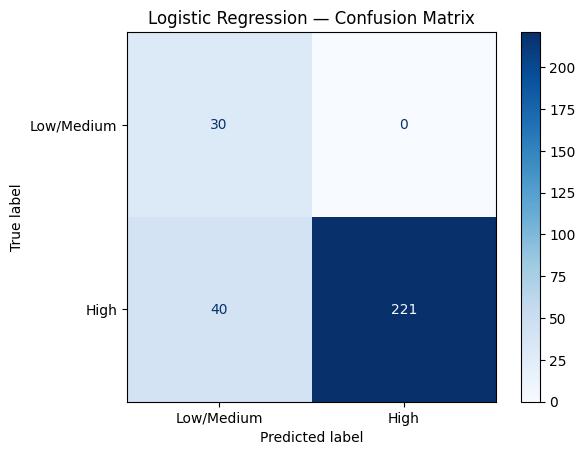

In [20]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low/Medium', 'High'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression — Confusion Matrix')
plt.show()

In [21]:
cv_scores_macro = cross_val_score(lr_model, X_train, y_train, cv=5, scoring='f1_macro')

print(f"5-Fold CV Macro F1 Scores: {cv_scores_macro.round(3)}")
print(f"Mean Macro F1: {cv_scores_macro.mean():.3f} (+/- {cv_scores_macro.std():.3f})")

5-Fold CV Macro F1 Scores: [0.786 0.821 0.753 0.826 0.712]
Mean Macro F1: 0.780 (+/- 0.043)
